# Imports

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Chargement des données + Train/Test split

In [13]:
df = pd.read_csv("../data/processed/feature_engineered_telco_churn.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline

In [14]:
log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=6000))
    ]
)

log_model.fit(X_train, y_train)

log_pred_proba = log_model.predict_proba(X_test)[:,1]

roc_log = roc_auc_score(y_test, log_pred_proba)

roc_log

0.8373966589187817

# Random Forest

In [19]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred_proba = rf_model.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, rf_pred_proba)

roc_rf

0.8356650325359397

Il semblerait que actuellement, le RandomForest ait plus de mal à prédire la cible que le LogisticRegressor. Sachant que le RandomForest capte mieux les relations non linéaire, ceci pourrait vouloir dire que le problème n'est pas dû à une multicolinéarité.

# XGBoost

In [33]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_pred_proba = xgb_model.predict_proba(X_test)[:,1]

roc_xgb = roc_auc_score(y_test, xgb_pred_proba)

roc_xgb

0.8355834985582722

# Comparaison des performances

In [34]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "ROC_AUC": [roc_log, roc_rf, roc_xgb]
})

results.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC
0,Logistic Regression,0.837397
1,Random Forest,0.835665
2,XGBoost,0.835583


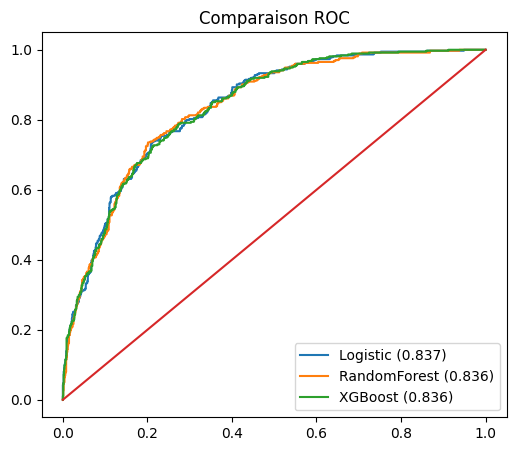

In [35]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic ({roc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest ({roc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost ({roc_xgb:.3f})")

plt.plot([0,1],[0,1])
plt.legend()
plt.title("Comparaison ROC")
plt.show()

# Importance des variables

In [27]:
feature_names = (
    log_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = xgb_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
32,cat__Contract_Month-to-month,0.271794
54,num__is_new_client,0.075132
12,cat__InternetService_Fiber optic,0.074066
14,cat__OnlineSecurity_No,0.066511
23,cat__TechSupport_No,0.053595
11,cat__InternetService_DSL,0.049413
34,cat__Contract_Two year,0.042627
33,cat__Contract_One year,0.027176
41,cat__tenure_group_0-12 mois,0.018715
50,num__tenure,0.016492


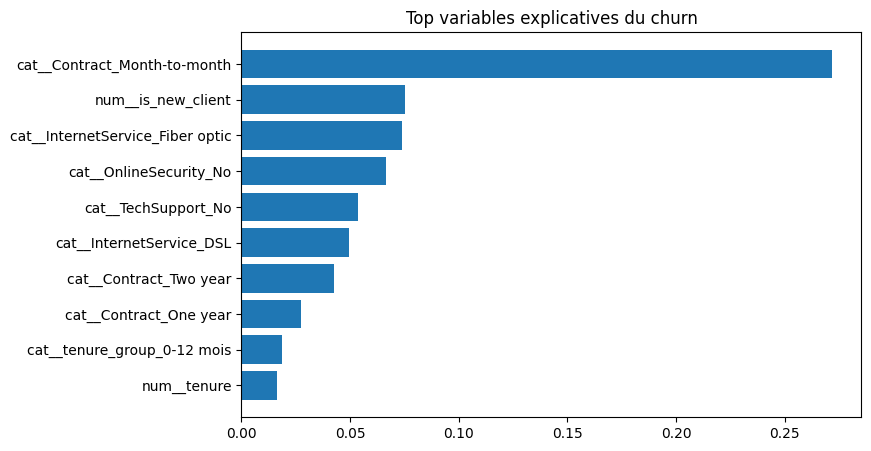

In [28]:
top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top variables explicatives du churn")
plt.show()

# Interprétation business

Les variables les plus explicatives du churn sont liées :
- au type de contrat
- à l'ancienneté client
- au service internet

Les clients récents avec un contrat mensuel et peu de services additionnels présentent le risque de churn le plus élevé.

# Construire un score churn

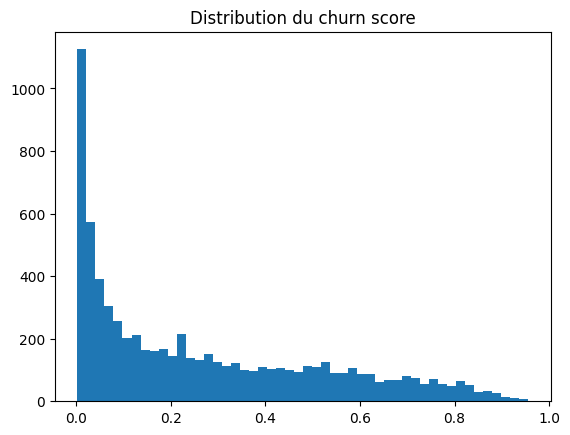

In [29]:
df["churn_score"] = log_model.predict_proba(X)[:,1]

plt.hist(df["churn_score"], bins=50)
plt.title("Distribution du churn score")
plt.show()

# Segmenter les clients par risque

In [31]:
df["risk_segment"] = pd.qcut(
    df["churn_score"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

In [32]:
df.groupby("risk_segment")["Churn"].mean()

C:\Users\QuentinGENSE\AppData\Local\Temp\ipykernel_19224\3207840668.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("risk_segment")["Churn"].mean()


risk_segment
Low          0.019909
Medium       0.108077
High         0.298066
Very High    0.637088
Name: Churn, dtype: float64

In [37]:
joblib.dump(log_model, "../models/churn_model_log.pkl")
joblib.dump(rf_model, "../models/churn_model_rf.pkl")
joblib.dump(xgb_model, "../models/churn_model_xgb.pkl")

['../models/churn_model_xgb.pkl']